In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
from scipy.sparse import hstack, csr_matrix

optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\janca\anaconda3\envs\XGBoost\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2: Load Data
df = pd.read_csv('Student-Discipline-Office-Violations-Dataset.csv')  # <-- change this
print(df.shape)
print(df.head())
print(df['Sanction'].value_counts())

(2002, 5)
                                            Scenario        Category  \
0  A student was spotted wearing casual clothes w...  Minor Offenses   
1  A student was seen entering the LRC without we...  Minor Offenses   
2  During a campus event, a student was found wea...  Minor Offenses   
3  A student was caught wearing a jeans in the ca...  Minor Offenses   
4  A student attended a lecture in the AVR wearin...  Minor Offenses   

                                           Violation Number of Offense  \
0  Non-wearing of the prescribed uniform inside t...       1st Offense   
1  Non-wearing of the prescribed uniform inside t...       1st Offense   
2  Non-wearing of the prescribed uniform inside t...       2nd Offense   
3  Non-wearing of the prescribed uniform inside t...       2nd Offense   
4  Non-wearing of the prescribed uniform inside t...       1st Offense   

                                            Sanction  
0                   Violation slip issued by the SDO  
1 

In [3]:
# Cell 3: Clean Text & Numeric Columns
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Clean text columns
text_cols = ['Scenario', 'Category', 'Violation']
for col in text_cols:
    df[col] = df[col].apply(clean_text)

df['combined_text'] = df['Scenario'] + ' ' + df['Category'] + ' ' + df['Violation']

# ---- Fix 'Number of Offense' dtype issue ----
print("Unique values BEFORE cleaning:", df['Number of Offense'].unique())

df['Number of Offense'] = (
    df['Number of Offense']
    .astype(str)
    .str.extract(r'(\d+)')[0]
)
df['Number of Offense'] = pd.to_numeric(df['Number of Offense'], errors='coerce')
df['Number of Offense'] = df['Number of Offense'].fillna(0).astype(np.float64)

print("Unique values AFTER cleaning:", df['Number of Offense'].unique())

Unique values BEFORE cleaning: <StringArray>
['1st Offense', '2nd Offense', '3rd Offense']
Length: 3, dtype: str
Unique values AFTER cleaning: [1. 2. 3.]


In [4]:
# Cell 4: Feature Engineering (Tokenization + TF-IDF)
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2
)

X_text = tfidf.fit_transform(df['combined_text'])
X_numeric = csr_matrix(df[['Number of Offense']].values)

X = hstack([X_text, X_numeric]).tocsr()

le = LabelEncoder()
y = le.fit_transform(df['Sanction'])

print("Classes:", le.classes_)
print("Feature matrix shape:", X.shape)

Classes: ['Category 1 (Probation for 3 academic terms and referral for counseling)'
 'Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation)'
 'Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation) & 0.0 in the course'
 'Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation) and item confiscation'
 'Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation), charged for damages'
 'Category 3 (Non-Readmission, denial of admission but is allowed to finish current term)'
 'Category 3 (Non-Readmission, denial of admission but is allowed to finish current term) & 0.0 in the course'
 'Category 3 (Non-Readmission, denial of admission but is allowed to finish current term) and item confiscation'
 'Category 3 (Non-Readmission, denial of admission but is allowed to finish cu

In [5]:
# Cell 5: Train / Val / Test Split
# Train+Val vs Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Train vs Val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (1445, 501) | Val: (256, 501) | Test: (301, 501)


In [6]:
# Cell 6: Apply SMOTE (Train Only)
print("Before SMOTE:", np.bincount(y_train))

min_class_count = min(np.bincount(y_train))
k_neighbors = min(5, max(1, min_class_count - 1))

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [ 27 379  18   7  28 683  12   2  14  69  37  72  97]
After SMOTE: [683 683 683 683 683 683 683 683 683 683 683 683 683]


In [7]:
# Cell 7: Overfit Guard Callback
class OverfitGuardCallback(xgb.callback.TrainingCallback):
    """
    Stops training if:
    1. Train accuracy exceeds max_train_acc (e.g. 99.9%) -> model is memorizing
    2. Train-Val accuracy gap exceeds max_gap -> overfitting
    """
    def __init__(self, X_train, y_train, X_val, y_val,
                 max_train_acc=0.999, max_gap=0.15, check_every=5, verbose=True):
        self.dtrain_check = xgb.DMatrix(X_train)
        self.y_train = y_train
        self.dval_check = xgb.DMatrix(X_val)
        self.y_val = y_val
        self.max_train_acc = max_train_acc
        self.max_gap = max_gap
        self.check_every = check_every
        self.verbose = verbose
        self.history = []

    def after_iteration(self, model, epoch, evals_log):
        if epoch % self.check_every != 0:
            return False

        train_pred = model.predict(self.dtrain_check)
        val_pred = model.predict(self.dval_check)

        if train_pred.ndim > 1:
            train_pred = np.argmax(train_pred, axis=1)
            val_pred = np.argmax(val_pred, axis=1)

        train_acc = accuracy_score(self.y_train, train_pred)
        val_acc = accuracy_score(self.y_val, val_pred)
        gap = train_acc - val_acc

        self.history.append({
            'epoch': epoch, 'train_acc': train_acc,
            'val_acc': val_acc, 'gap': gap
        })

        if self.verbose:
            print(f"[Epoch {epoch}] Train Acc: {train_acc:.4f} | "
                  f"Val Acc: {val_acc:.4f} | Gap: {gap:.4f}")

        if train_acc >= self.max_train_acc:
            print(f"\n🛑 STOPPING: Train accuracy hit {train_acc:.4f} "
                  f"(threshold {self.max_train_acc}) — model is memorizing!")
            return True

        if gap >= self.max_gap:
            print(f"\n🛑 STOPPING: Train-Val gap hit {gap:.4f} "
                  f"(threshold {self.max_gap}) — overfitting detected!")
            return True

        return False

In [8]:
# Cell 8: Optuna Objective (with Early Stopping + Overfit Guard)
def objective(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': len(le.classes_),
        'eval_metric': 'mlogloss',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('learning_rate', 0.001, 0.03, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'tree_method': 'hist',
        'seed': 42
    }

    dtrain = xgb.DMatrix(X_train_res, label=y_train_res)
    dval = xgb.DMatrix(X_val, label=y_val)

    guard = OverfitGuardCallback(
        X_train_res, y_train_res, X_val, y_val,
        max_train_acc=0.999, max_gap=0.20, check_every=10, verbose=False
    )

    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtrain, 'train'), (dval, 'val')],
        callbacks=[
            xgb.callback.EarlyStopping(rounds=30, save_best=True),
            guard
        ],
        verbose_eval=False
    )

    val_pred = booster.predict(dval)
    val_pred_labels = np.argmax(val_pred, axis=1)
    score = f1_score(y_val, val_pred_labels, average='macro')

    trial.set_user_attr('best_iteration', booster.best_iteration)

    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best F1 score:", study.best_value)
print("Best iteration:", study.best_trial.user_attrs.get('best_iteration'))

Best trial: 1. Best value: 0.695247:   4%|▍         | 2/50 [00:00<00:07,  6.58it/s]


🛑 STOPPING: Train-Val gap hit 0.2451 (threshold 0.2) — overfitting detected!

🛑 STOPPING: Train-Val gap hit 0.2398 (threshold 0.2) — overfitting detected!


Best trial: 2. Best value: 0.703148:   8%|▊         | 4/50 [00:01<00:15,  2.88it/s]


🛑 STOPPING: Train-Val gap hit 0.2027 (threshold 0.2) — overfitting detected!

🛑 STOPPING: Train-Val gap hit 0.2865 (threshold 0.2) — overfitting detected!


Best trial: 2. Best value: 0.703148:  12%|█▏        | 6/50 [00:01<00:09,  4.65it/s]

...


🛑 STOPPING: Train-Val gap hit 0.2032 (threshold 0.2) — overfitting detected!

🛑 STOPPING: Train-Val gap hit 0.2136 (threshold 0.2) — overfitting detected!


Best trial: 28. Best value: 0.801912:  82%|████████▏ | 41/50 [11:49<02:21, 15.71s/it]


🛑 STOPPING: Train-Val gap hit 0.2063 (threshold 0.2) — overfitting detected!


Best trial: 28. Best value: 0.801912: 100%|██████████| 50/50 [22:45<00:00, 27.31s/it]

Best params: {'max_depth': 10, 'learning_rate': 0.0030759565914126276, 'subsample': 0.6508191813102754, 'colsample_bytree': 0.7957110826418944, 'min_child_weight': 1, 'gamma': 1.4381940835041678, 'reg_alpha': 4.828972157305342, 'reg_lambda': 2.987462156236626}
Best F1 score: 0.8019121513953557
Best iteration: 999


In [9]:
# Cell 9: Train Final Model
best_params = study.best_params.copy()
best_params['eta'] = best_params.pop('learning_rate')  # native API uses 'eta'
best_params.update({
    'objective': 'multi:softprob',
    'num_class': len(le.classes_),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'seed': 42
})

dtrain = xgb.DMatrix(X_train_res, label=y_train_res)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

evals_result = {}

final_guard = OverfitGuardCallback(
    X_train_res, y_train_res, X_val, y_val,
    max_train_acc=0.999, max_gap=0.20, check_every=5, verbose=True
)

final_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    callbacks=[
        xgb.callback.EarlyStopping(rounds=30, save_best=True),
        final_guard
    ],
    evals_result=evals_result,
    verbose_eval=10
)

print(f"\n✅ Best iteration: {final_model.best_iteration}")

[Epoch 0] Train Acc: 0.9798 | Val Acc: 0.8359 | Gap: 0.1439
[0]	train-mlogloss:2.54833	val-mlogloss:2.55391
[Epoch 5] Train Acc: 0.9796 | Val Acc: 0.8164 | Gap: 0.1632
[Epoch 10] Train Acc: 0.9813 | Val Acc: 0.8242 | Gap: 0.1571
[10]	train-mlogloss:2.39821	val-mlogloss:2.45303
[Epoch 15] Train Acc: 0.9838 | Val Acc: 0.8477 | Gap: 0.1361
[Epoch 20] Train Acc: 0.9855 | Val Acc: 0.8555 | Gap: 0.1300
[20]	train-mlogloss:2.26490	val-mlogloss:2.35998
[Epoch 25] Train Acc: 0.9845 | Val Acc: 0.8516 | Gap: 0.1329
[Epoch 30] Train Acc: 0.9857 | Val Acc: 0.8555 | Gap: 0.1302
[30]	train-mlogloss:2.14731	val-mlogloss:2.27474
[Epoch 35] Train Acc: 0.9851 | Val Acc: 0.8516 | Gap: 0.1336
[Epoch 40] Train Acc: 0.9855 | Val Acc: 0.8477 | Gap: 0.1378
[40]	train-mlogloss:2.04211	val-mlogloss:2.19712
[Epoch 45] Train Acc: 0.9836 | Val Acc: 0.8281 | Gap: 0.1554
[Epoch 50] Train Acc: 0.9847 | Val Acc: 0.8398 | Gap: 0.1448
[50]	train-mlogloss:1.94629	val-mlogloss:2.12514
[Epoch 55] Train Acc: 0.9856 | Val Acc

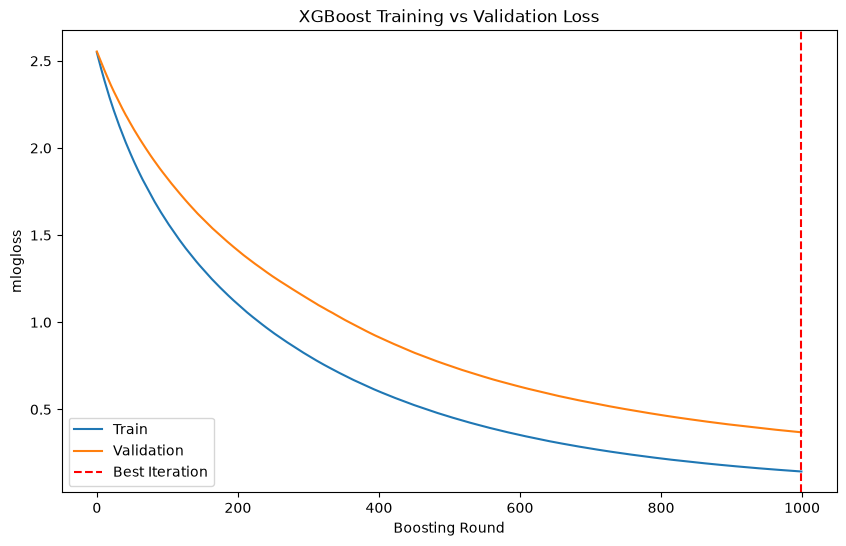

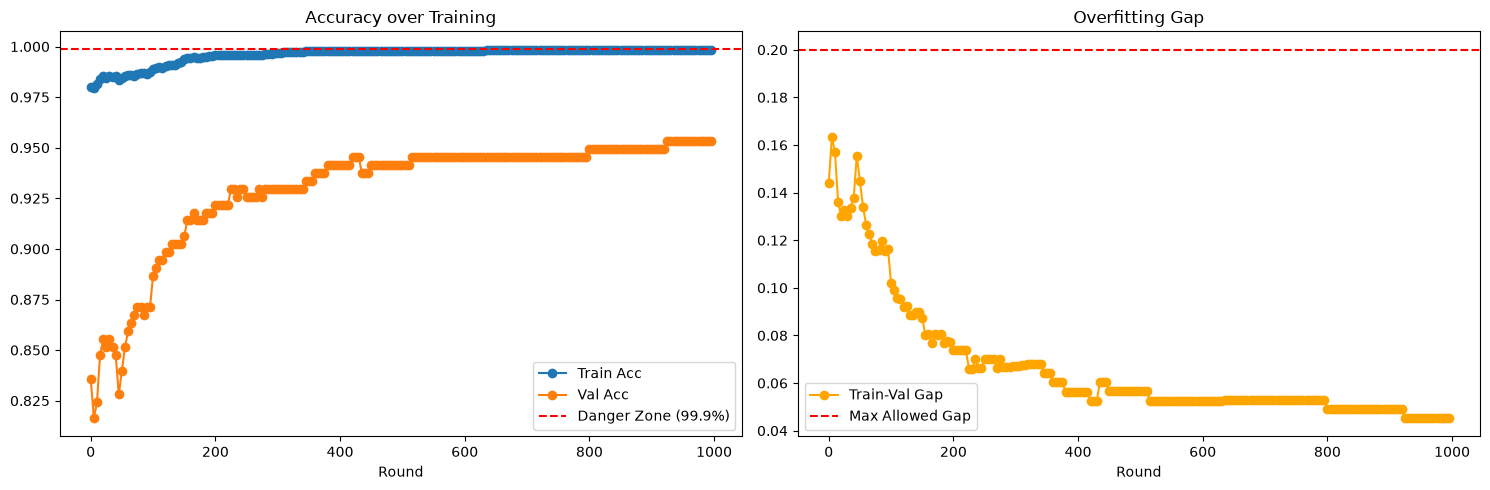

In [10]:
# Cell 10: Plot Training Curves
epochs = len(evals_result['train']['mlogloss'])
x_axis = range(epochs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_axis, evals_result['train']['mlogloss'], label='Train')
ax.plot(x_axis, evals_result['val']['mlogloss'], label='Validation')
ax.axvline(final_model.best_iteration, color='red', linestyle='--', label='Best Iteration')
ax.legend()
plt.ylabel('mlogloss')
plt.xlabel('Boosting Round')
plt.title('XGBoost Training vs Validation Loss')
plt.show()

# Overfit guard history
if final_guard.history:
    hist_df = pd.DataFrame(final_guard.history)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(hist_df['epoch'], hist_df['train_acc'], label='Train Acc', marker='o')
    axes[0].plot(hist_df['epoch'], hist_df['val_acc'], label='Val Acc', marker='o')
    axes[0].axhline(0.999, color='red', linestyle='--', label='Danger Zone (99.9%)')
    axes[0].set_title('Accuracy over Training')
    axes[0].set_xlabel('Round')
    axes[0].legend()

    axes[1].plot(hist_df['epoch'], hist_df['gap'], label='Train-Val Gap', color='orange', marker='o')
    axes[1].axhline(0.20, color='red', linestyle='--', label='Max Allowed Gap')
    axes[1].set_title('Overfitting Gap')
    axes[1].set_xlabel('Round')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [11]:
# Cell 11: Evaluate on Test Set
y_pred_proba = final_model.predict(dtest)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# Overfitting check
train_pred_proba = final_model.predict(dtrain)
train_pred = np.argmax(train_pred_proba, axis=1)
train_f1 = f1_score(y_train_res, train_pred, average='macro')
test_f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nTrain F1: {train_f1:.4f}")
print(f"Test F1: {test_f1:.4f}")
print(f"Gap: {train_f1 - test_f1:.4f}")

if train_f1 - test_f1 > 0.15:
    print("⚠️ Warning: Large gap suggests overfitting.")
else:
    print("✅ Train/Test gap looks reasonable")

                                                                                                                                       precision    recall  f1-score   support

                                                              Category 1 (Probation for 3 academic terms and referral for counseling)       0.86      1.00      0.92         6
                      Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation)       0.99      0.92      0.95        79
  Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation) & 0.0 in the course       1.00      0.75      0.86         4
Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation) and item confiscation       1.00      1.00      1.00         1
 Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation), charged fo

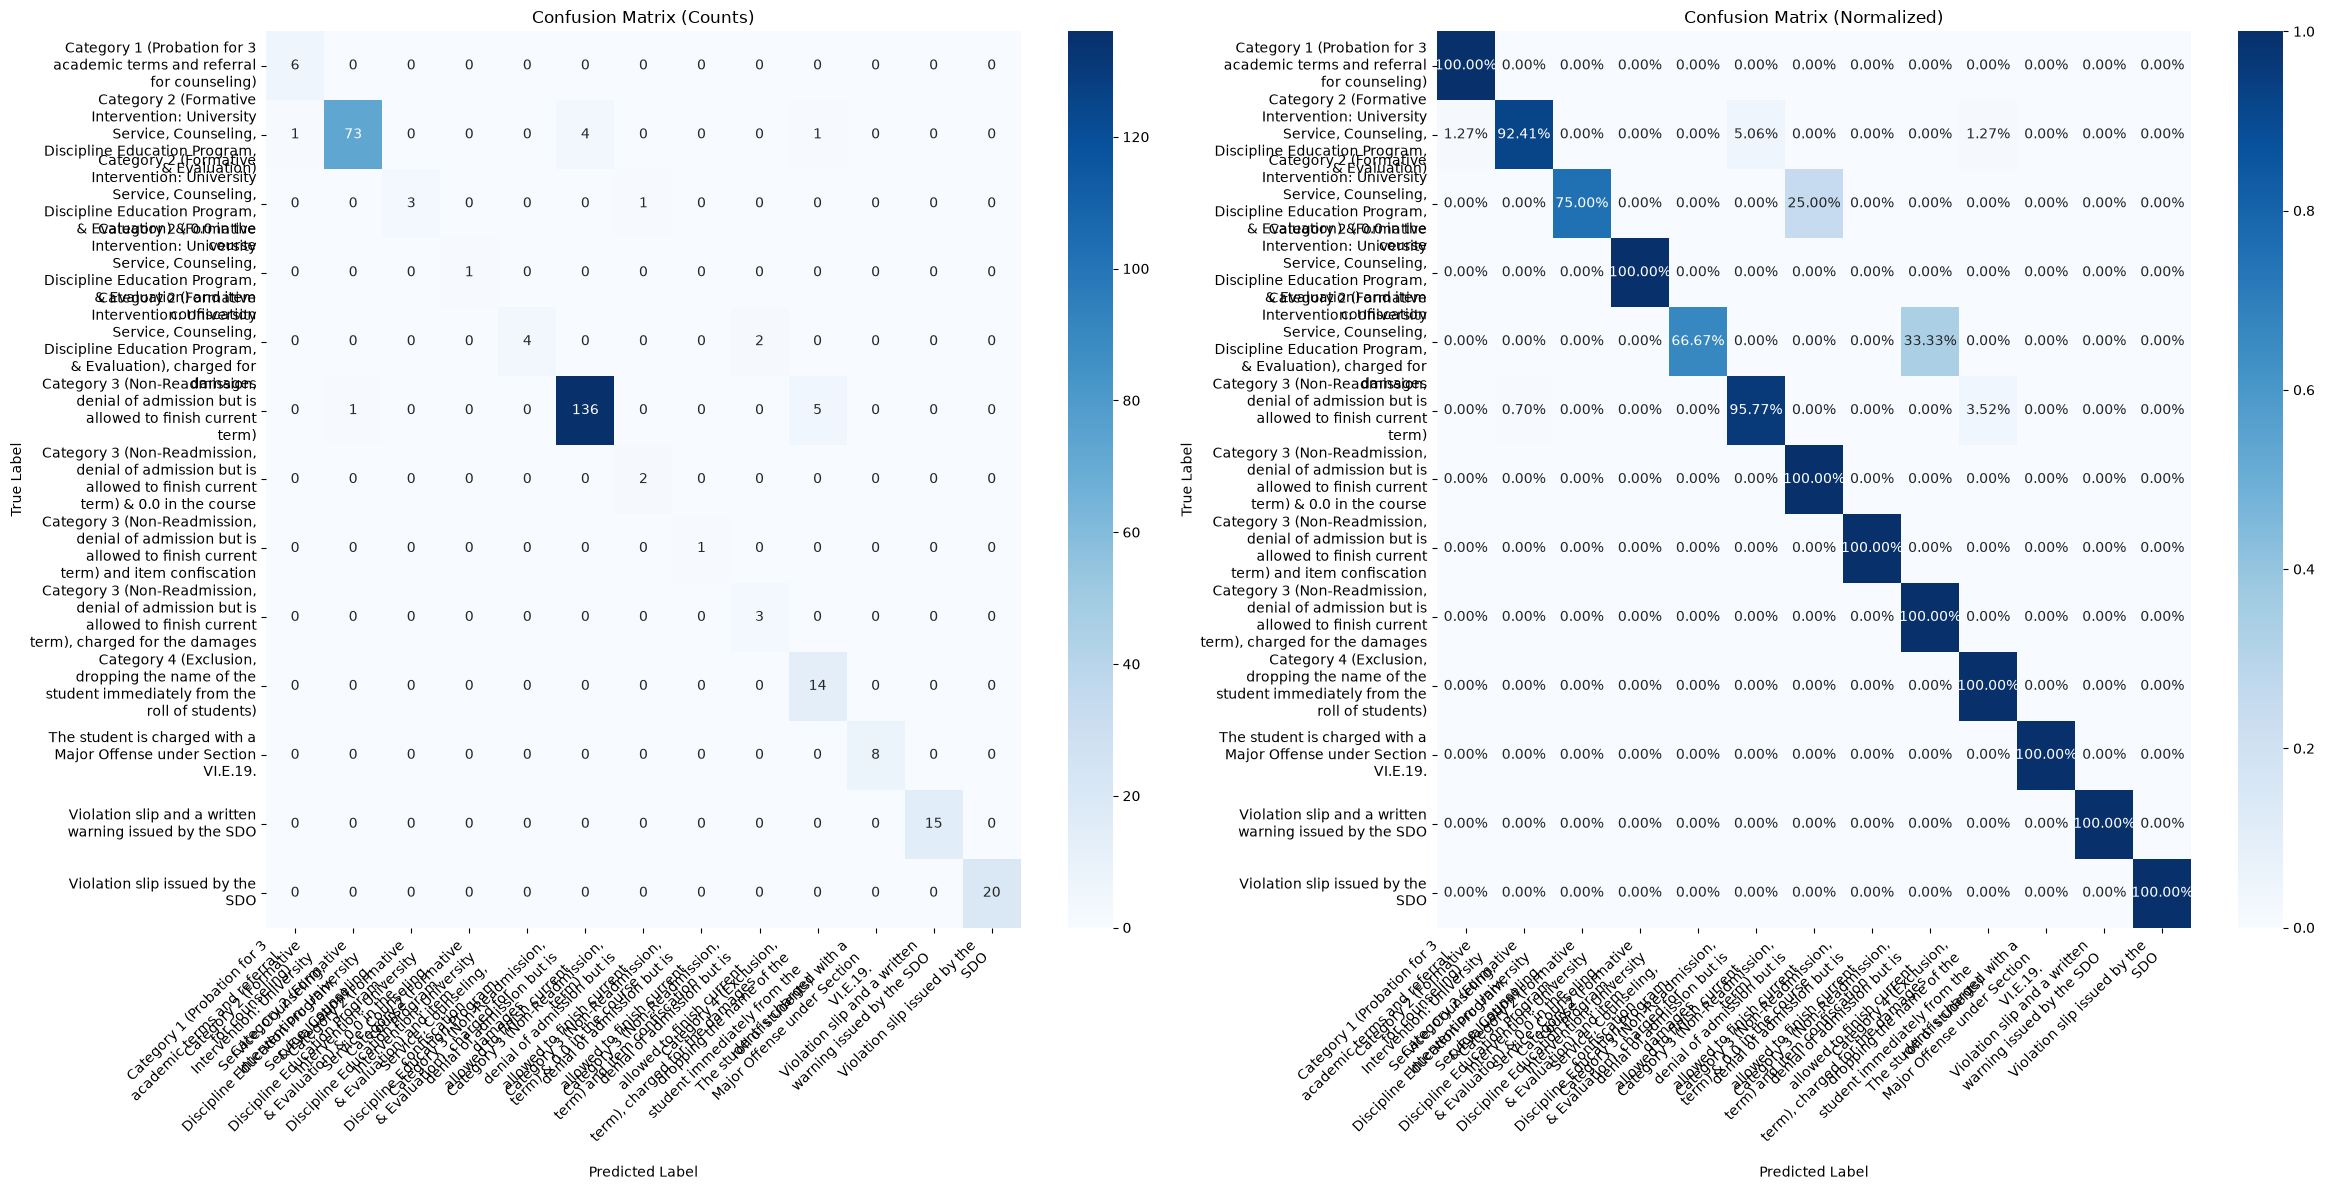

In [12]:
import textwrap

# Cell 12: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Wrap the long class labels to 30 characters per line so they don't squish the heatmap
wrapped_labels = [textwrap.fill(str(label), width=30) for label in le.classes_]

# Increased figsize to give more room for the large labels
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wrapped_labels, yticklabels=wrapped_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=wrapped_labels, yticklabels=wrapped_labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [13]:
# Cell 13: Save Model & Artifacts
final_model.save_model('sanction_xgb_model.json')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("✅ Model and artifacts saved!")

✅ Model and artifacts saved!


In [14]:
# Cell 14: Manual Testing

def predict_sanction(scenario, category, violation, num_offense):
    # 1. Clean the text inputs individually just like during training
    clean_scenario = clean_text(scenario)
    clean_category = clean_text(category)
    clean_violation = clean_text(violation)
    
    # Combine them into a single string
    combined = f"{clean_scenario} {clean_category} {clean_violation}"
    
    # 2. Transform text using the already fitted TF-IDF vectorizer
    X_text_manual = tfidf.transform([combined])
    
    # 3. Process the 'Number of Offense' feature
    match = re.search(r'(\d+)', str(num_offense))
    num = float(match.group(1)) if match else 0.0
    
    X_numeric_manual = csr_matrix([[num]])
    
    # 4. Combine text and numeric features together
    X_manual = hstack([X_text_manual, X_numeric_manual]).tocsr()
    
    # 5. Create the DMatrix and Predict
    dmanual = xgb.DMatrix(X_manual)
    probs = final_model.predict(dmanual)
    
    # 6. Get the predicted label and confidence score
    pred_idx = np.argmax(probs, axis=1)[0]
    pred_label = le.inverse_transform([pred_idx])[0]
    confidence = probs[0][pred_idx]
    
    print("--- Manual Prediction ---")
    print(f"Predicted Sanction : {pred_label}")
    print(f"Confidence         : {confidence:.2%}")
    print("\nTop 3 Probabilities:")
    
    # Print the top 3 most likely sanctions for better insight
    top_3_indices = np.argsort(probs[0])[::-1][:3]
    for idx in top_3_indices:
        label = le.inverse_transform([idx])[0]
        prob = probs[0][idx]
        print(f" - {prob:.2%} : {label}")

# --- You can change these values to test different cases ---
test_scenario = "I forgot to bring my ID"
test_category = "Minor Offenses"
test_violation = "Non-wearing of ID"
test_num_offense = "1st Offense"

# Run the prediction
predict_sanction(test_scenario, test_category, test_violation, test_num_offense)


--- Manual Prediction ---
Predicted Sanction : Violation slip issued by the SDO
Confidence         : 86.92%

Top 3 Probabilities:
 - 86.92% : Violation slip issued by the SDO
 - 2.62% : Violation slip and a written warning issued by the SDO
 - 2.23% : Category 2 (Formative Intervention: University Service, Counseling, Discipline Education Program, & Evaluation)


In [15]:
# Cell 15: Inference Function
def predict_sanction(scenario, category, violation, num_offense):
    text = clean_text(scenario + ' ' + category + ' ' + violation)
    X_text_new = tfidf.transform([text])
    X_num_new = csr_matrix([[float(num_offense)]])
    X_new = hstack([X_text_new, X_num_new]).tocsr()

    dnew = xgb.DMatrix(X_new)
    pred_proba = final_model.predict(dnew)
    pred_class = np.argmax(pred_proba, axis=1)[0]

    sanction = le.inverse_transform([pred_class])[0]
    confidence = pred_proba[0][pred_class]

    return sanction, confidence


# Example usage
sanction, conf = predict_sanction(
    "Employee arrived late multiple times",
    "Attendance",
    "Tardiness",
    3
)
print(f"Predicted Sanction: {sanction} (Confidence: {conf:.2%})")

Predicted Sanction: The student is charged with a Major Offense under Section VI.E.19. (Confidence: 69.60%)
